In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1       85             66  ...                     0.351   31        0
2            8      183             64  ...                     0.672   32        1
3            1       89             66  ...                     0.167   21        0
4            0      137             40  ...                     2.288   33        1

[5 rows x 9 columns]

Shape of dataset:
(768, 9)


In [3]:
# Select numerical variable
glucose = df["Glucose"]

print("Selected variable: Glucose")
print("Mean Glucose:", glucose.mean())
print("Standard Deviation:", glucose.std())

Selected variable: Glucose
Mean Glucose: 120.89453125
Standard Deviation: 31.97261819513622


In [4]:
# Number of bootstrap samples
n_bootstrap = 1000

# Store bootstrap means
bootstrap_means = []

# Bootstrap sampling
for i in range(n_bootstrap):
    sample = glucose.sample(
        n=len(glucose),
        replace=True,
        random_state=i
    )

    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

print("Number of bootstrap samples:", len(bootstrap_means))
print("First 10 bootstrap means:")
print(bootstrap_means[:10])

Number of bootstrap samples: 1000
First 10 bootstrap means:
[120.54817708 121.74479167 122.76302083 120.88802083 119.94270833
 120.34765625 119.69401042 120.64583333 121.47265625 119.99739583]


In [5]:
print("Original sample mean:", glucose.mean())
print("Bootstrap mean:", bootstrap_means.mean())
print("Bootstrap standard deviation:", bootstrap_means.std())

Original sample mean: 120.89453125
Bootstrap mean: 120.9189453125
Bootstrap standard deviation: 1.159026113399354


In [6]:
# 95% Bootstrap Confidence Interval

lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("95% Bootstrap Confidence Interval:")
print("Lower limit:", lower)
print("Upper limit:", upper)

95% Bootstrap Confidence Interval:
Lower limit: 118.70048828124999
Upper limit: 123.16588541666667


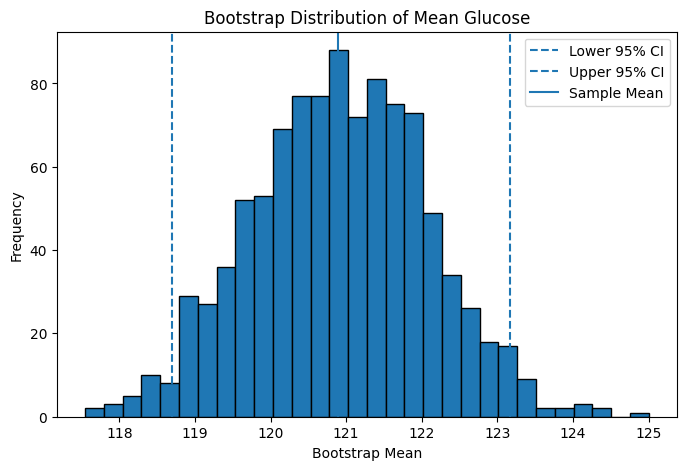

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(bootstrap_means, bins=30, edgecolor="black")

plt.axvline(
    lower,
    linestyle="--",
    label="Lower 95% CI"
)

plt.axvline(
    upper,
    linestyle="--",
    label="Upper 95% CI"
)

plt.axvline(
    glucose.mean(),
    linestyle="-",
    label="Sample Mean"
)

plt.title("Bootstrap Distribution of Mean Glucose")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [8]:
# Divide data into two groups

group_0 = df[df["Outcome"] == 0]
group_1 = df[df["Outcome"] == 1]

print("Non-diabetic group:")
print("Number of observations:", len(group_0))
print("Mean Glucose:", group_0["Glucose"].mean())

print("\nDiabetic group:")
print("Number of observations:", len(group_1))
print("Mean Glucose:", group_1["Glucose"].mean())

Non-diabetic group:
Number of observations: 500
Mean Glucose: 109.98

Diabetic group:
Number of observations: 268
Mean Glucose: 141.25746268656715


In [9]:
# Calculate observed difference

mean_0 = group_0["Glucose"].mean()
mean_1 = group_1["Glucose"].mean()

observed_difference = mean_1 - mean_0

print("Mean Glucose - Non-diabetic:", mean_0)
print("Mean Glucose - Diabetic:", mean_1)
print("Observed difference:", observed_difference)

Mean Glucose - Non-diabetic: 109.98
Mean Glucose - Diabetic: 141.25746268656715
Observed difference: 31.277462686567148


In [10]:
# Number of permutations
n_permutations = 1000

permutation_differences = []

# Original glucose values
glucose_values = df["Glucose"].values

# Original group labels
outcomes = df["Outcome"].values.copy()

for i in range(n_permutations):

    # Randomly shuffle outcome labels
    shuffled_outcomes = np.random.permutation(outcomes)

    # Separate glucose values using shuffled labels
    shuffled_group_0 = glucose_values[shuffled_outcomes == 0]
    shuffled_group_1 = glucose_values[shuffled_outcomes == 1]

    # Calculate difference in means
    difference = (
        shuffled_group_1.mean()
        - shuffled_group_0.mean()
    )

    permutation_differences.append(difference)

permutation_differences = np.array(permutation_differences)

print("Number of permutations:", len(permutation_differences))

print("First 10 permutation differences:")
print(permutation_differences[:10])

Number of permutations: 1000
First 10 permutation differences:
[-2.63489552  5.34886567  0.05883582  0.23077612  2.84426866  0.56892537
 -0.59453731  2.20808955 -0.97853731 -3.68373134]


In [11]:
print("Mean of permutation differences:",
      permutation_differences.mean())

print("Standard deviation:",
      permutation_differences.std())

print("Minimum difference:",
      permutation_differences.min())

print("Maximum difference:",
      permutation_differences.max())

Mean of permutation differences: 0.018601791044776363
Standard deviation: 2.425958430109378
Minimum difference: -8.148447761194035
Maximum difference: 7.480925373134326


In [12]:
# Calculate permutation p-value

p_value = np.mean(
    np.abs(permutation_differences)
    >= np.abs(observed_difference)
)

print("Observed difference:", observed_difference)
print("Permutation p-value:", p_value)

Observed difference: 31.277462686567148
Permutation p-value: 0.0


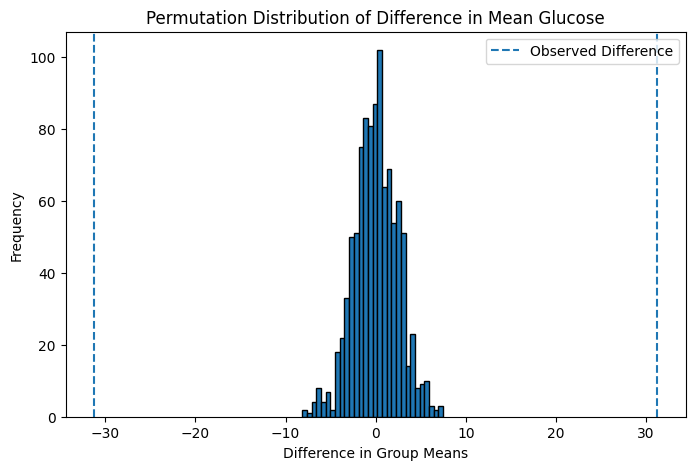

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    permutation_differences,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    observed_difference,
    linestyle="--",
    label="Observed Difference"
)

plt.axvline(
    -observed_difference,
    linestyle="--"
)

plt.title("Permutation Distribution of Difference in Mean Glucose")
plt.xlabel("Difference in Group Means")
plt.ylabel("Frequency")

plt.legend()

plt.show()

In [14]:
alpha = 0.05

print("\nFinal Decision:")

if p_value < alpha:
    print("Reject H0")
    print(
        "There is a statistically significant "
        "difference in mean glucose levels "
        "between diabetic and non-diabetic groups."
    )
else:
    print("Fail to reject H0")
    print(
        "There is no statistically significant "
        "difference in mean glucose levels "
        "between diabetic and non-diabetic groups."
    )


Final Decision:
Reject H0
There is a statistically significant difference in mean glucose levels between diabetic and non-diabetic groups.
